In [ ]:
import urllib.request

urllib.request.urlretrieve(
    'https://fred.stlouisfed.org/graph/fredgraph.csv?id=DEXUSAL',
    '/content/DEXUSAL.csv'
)
print('Dataset descargado correctamente.')

Dataset descargado correctamente.


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/DEXUSAL.csv')
print("Columnas:", df.columns.tolist())
df.head()

Columnas: ['observation_date', 'DEXUSAL']


,observation_date,DEXUSAL
0,1971-01-04,1.1127
1,1971-01-05,1.1132
2,1971-01-06,1.1140
3,1971-01-07,1.1138
4,1971-01-08,1.1124


In [ ]:
# FRED usa '.' para valores faltantes — convertir a NaN
df['DEXUSAL'] = pd.to_numeric(df['DEXUSAL'], errors='coerce')

# Convertir observation_date a datetime
df['observation_date'] = pd.to_datetime(df['observation_date'])

# Ordenar por fecha
df = df.sort_values('observation_date').reset_index(drop=True)

# Eliminar nulos (fines de semana / festivos sin cotización)
df = df.dropna().reset_index(drop=True)

df.head()


,observation_date,DEXUSAL
0,1971-01-04,1.1127
1,1971-01-05,1.1132
2,1971-01-06,1.1140
3,1971-01-07,1.1138
4,1971-01-08,1.1124


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13833 entries, 0 to 13832
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   observation_date  13833 non-null  datetime64[ns]
 1   DEXUSAL           13833 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 216.3 KB


In [ ]:
fecha_inicio = df['observation_date'].min()
fecha_fin = df['observation_date'].max()
fecha_inicio, fecha_fin

(Timestamp('1971-01-04 00:00:00'), Timestamp('2026-03-13 00:00:00'))

In [ ]:
serie = df['DEXUSAL'].values

In [ ]:
serie = serie[np.isfinite(serie)]

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
serie_scaled = scaler.fit_transform(serie.reshape(-1, 1))

In [ ]:
def create_dataset(series, n_steps):
    X, y = [], []
    for i in range(len(series) - n_steps):
        X.append(series[i:i+n_steps])
        y.append(series[i+n_steps])
    return np.array(X), np.array(y)

n_steps = 30  # ventana de 30 días

X, y = create_dataset(serie_scaled, n_steps)

In [ ]:
split = int(0.7 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Para BiLSTM — mantener forma (N, 30, 1)
X_train_rnn = X_train  # ya tiene forma (N, 30, 1)
X_test_rnn  = X_test

print(f'Train RNN : {X_train_rnn.shape} | Test RNN : {X_test_rnn.shape}')

#se mantiene en 3 dimensiones porque necesita la dimensión de secuencia explícita

Train RNN : (9662, 30, 1) | Test RNN : (4141, 30, 1)


In [ ]:
import torch
import torch.nn as nn

class BiLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(   #instancia lstm de pytorch
            input_size=1,      # 1 feature por paso de tiempo (el tipo de cambio)
            hidden_size=50,    # 50 neuronas por dirección
            num_layers=2,      # 2 capas apiladas
            batch_first=True,  # espera entrada (batch, secuencia, features)
            bidirectional=True # lee hacia adelante Y hacia atrás
        )
        # hidden_size * 2 porque bidireccional duplica la salida (50 forward + 50 backward)
        self.fc = nn.Linear(100, 1)#es la full conectec que recibe el vector 100 elementos y devuelve 1

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]   # tomar solo el último paso de tiempo
        return self.fc(out)


In [ ]:
def train_model(model, X_train, y_train, X_test, y_test, epochs=20):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    train_losses, test_losses = [], []

    for epoch in range(epochs):
        model.train()
        X_t = torch.tensor(X_train, dtype=torch.float32)
        y_t = torch.tensor(y_train, dtype=torch.float32)

        optimizer.zero_grad()
        pred = model(X_t)
        loss = criterion(pred, y_t)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            X_val = torch.tensor(X_test, dtype=torch.float32)
            y_val = torch.tensor(y_test, dtype=torch.float32)
            val_pred = model(X_val)
            val_loss = criterion(val_pred, y_val)

        train_losses.append(loss.item())
        test_losses.append(val_loss.item())
        print(f'Epoch {epoch+1:>2}/{epochs}  |  Loss: {loss.item():.5f}  |  Val: {val_loss.item():.5f}')

    return train_losses, test_losses

In [ ]:
bi_lstm_model = BiLSTM()

print('=== Entrenando BiLSTM ===')
train_loss_lstm, test_loss_lstm = train_model(
    bi_lstm_model, X_train_rnn, y_train, X_test_rnn, y_test
)

=== Entrenando BiLSTM ===
Epoch  1/20  |  Loss: 0.24787  |  Val: 0.12739
Epoch  2/20  |  Loss: 0.22763  |  Val: 0.11234
Epoch  3/20  |  Loss: 0.20850  |  Val: 0.09824
Epoch  4/20  |  Loss: 0.19031  |  Val: 0.08497
Epoch  5/20  |  Loss: 0.17285  |  Val: 0.07243
Epoch  6/20  |  Loss: 0.15599  |  Val: 0.06062
Epoch  7/20  |  Loss: 0.13962  |  Val: 0.04957
Epoch  8/20  |  Loss: 0.12373  |  Val: 0.03944
Epoch  9/20  |  Loss: 0.10840  |  Val: 0.03047
Epoch 10/20  |  Loss: 0.09378  |  Val: 0.02307
Epoch 11/20  |  Loss: 0.08019  |  Val: 0.01784
Epoch 12/20  |  Loss: 0.06813  |  Val: 0.01569
Epoch 13/20  |  Loss: 0.05841  |  Val: 0.01785
Epoch 14/20  |  Loss: 0.05223  |  Val: 0.02547
Epoch 15/20  |  Loss: 0.05095  |  Val: 0.03799
Epoch 16/20  |  Loss: 0.05494  |  Val: 0.05021
Epoch 17/20  |  Loss: 0.06090  |  Val: 0.05614
Epoch 18/20  |  Loss: 0.06389  |  Val: 0.05482
Epoch 19/20  |  Loss: 0.06247  |  Val: 0.04872
Epoch 20/20  |  Loss: 0.05817  |  Val: 0.04078


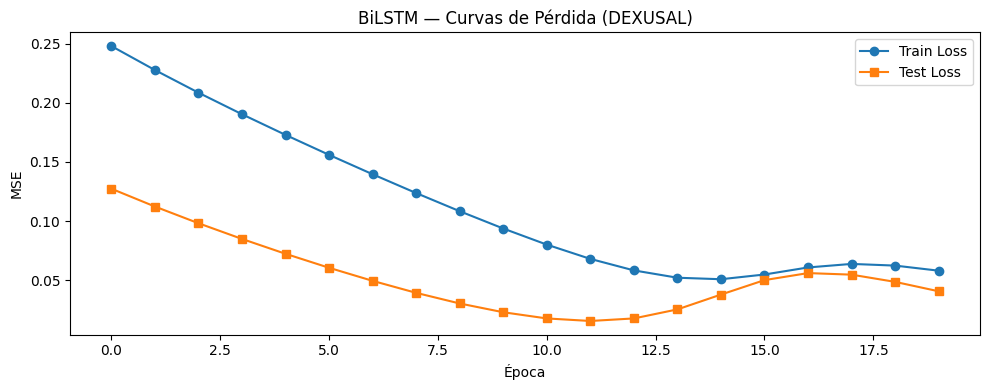

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(train_loss_lstm, label='Train Loss', marker='o')
plt.plot(test_loss_lstm,  label='Test Loss',  marker='s')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.title('BiLSTM — Curvas de Pérdida (DEXUSAL)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
bi_lstm_model.eval()
with torch.no_grad():
    preds_lstm = bi_lstm_model(torch.tensor(X_test_rnn, dtype=torch.float32)).numpy()

# Desnormalizar
y_test_inv     = scaler.inverse_transform(y_test)
preds_lstm_inv = scaler.inverse_transform(preds_lstm)

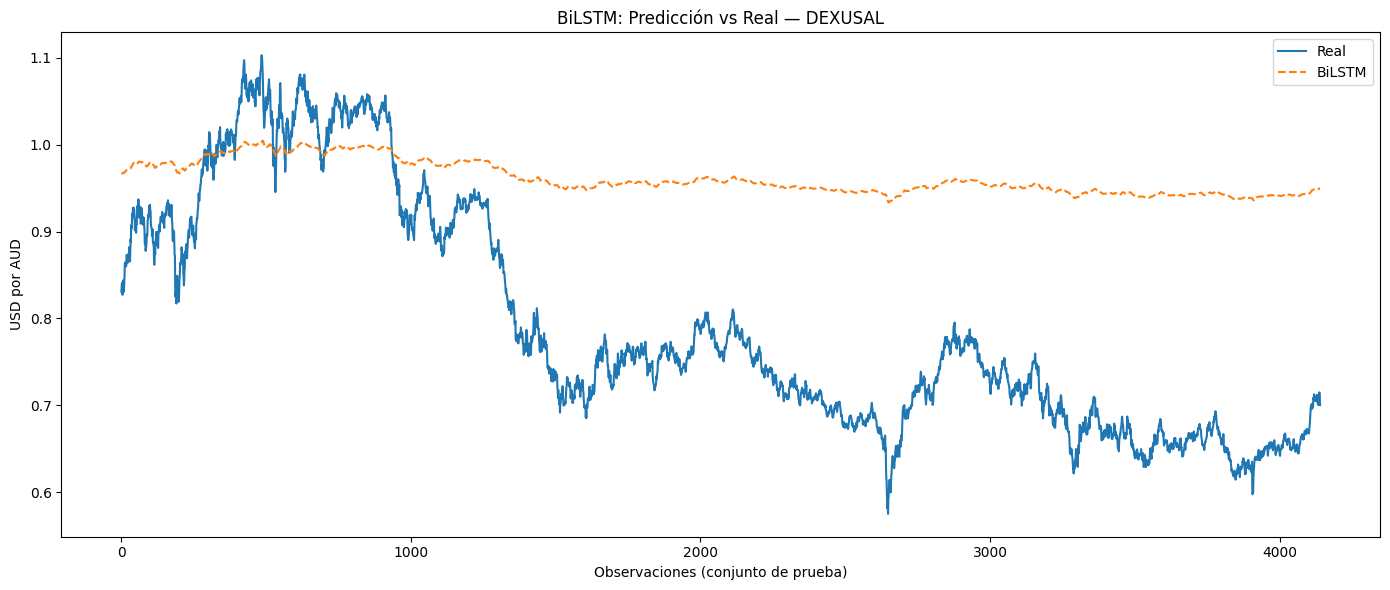

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(y_test_inv,     label='Real',   linewidth=1.5)
plt.plot(preds_lstm_inv, label='BiLSTM', linewidth=1.5, linestyle='--')
plt.xlabel('Observaciones (conjunto de prueba)')
plt.ylabel('USD por AUD')
plt.title('BiLSTM: Predicción vs Real — DEXUSAL')
plt.legend()
plt.tight_layout()
plt.show()

al modelo de cuesta aprender porque en el batche de entrenamiento le pasamos todos los batches de golpe, falta de epochs y la definicion de la red bilstm, pasan de la capa lstm a la fullconected directamente entonces se pierde mucha informacion, hay que medir una capa secuencial
